<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\tsito\AppData\Local\Temp\ipykernel_11876\3435421650.py:5: SyntaxWarning: invalid escape sequence '\m'
  metrics_path = Path("outputs\multi_bond\\bonds_02_05_06_07_08_10_14_18\metrics.json")


<Axes: xlabel='iteration'>

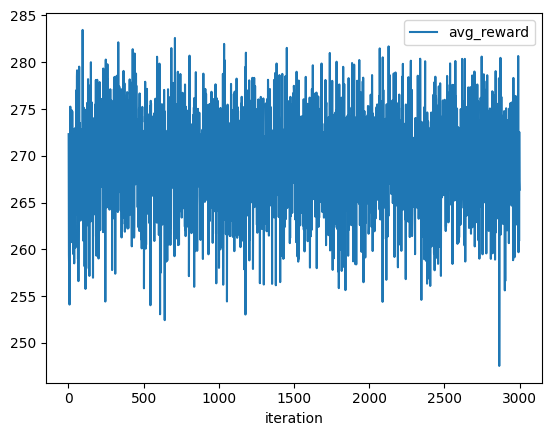

In [1]:
import json
import pandas as pd
from pathlib import Path

metrics_path = Path("outputs\multi_bond\\bonds_02_05_06_07_08_10_14_18\metrics.json")


with open(metrics_path, "r", encoding="utf-8") as f:
    metrics = json.load(f)

avg_reward = metrics["history"]["avg_reward_long"]

df = pd.DataFrame({
    "iteration": range(1, len(avg_reward) + 1),
    "avg_reward": avg_reward,
})

df.plot(x="iteration", y="avg_reward")

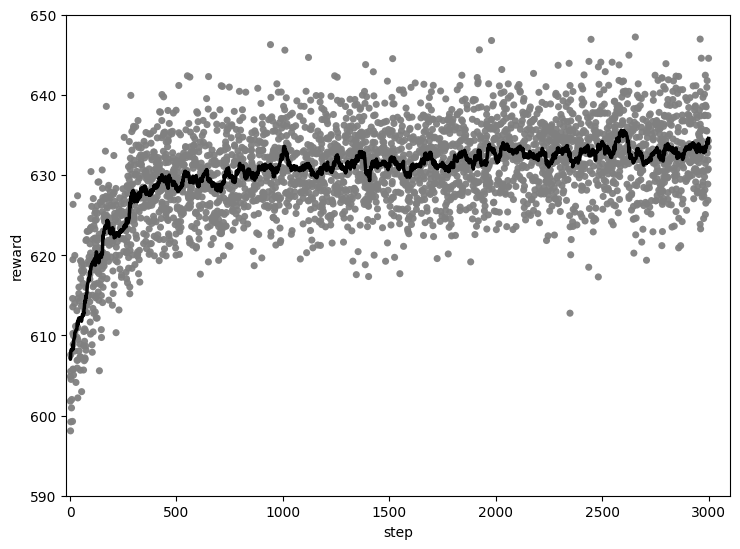

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n = 3200
x = np.sort(rng.uniform(0, 3000, n))

mu = (
    600
    + 17 * (1 - np.exp(-x / 140))
    + 16 * np.log1p(x) / np.log1p(3000)
)

sigma = 4.5 + 2.0 * np.exp(-x / 180)
y = mu + rng.normal(0, sigma, n)

df = pd.DataFrame({"x": x, "y": y}).sort_values("x")

# smaller window = rougher line
roll = df["y"].rolling(window=35, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(7.5, 5.6))

ax.scatter(df["x"], df["y"], s=26, color="gray", alpha=0.95, edgecolors="none")
ax.plot(df["x"], roll, color="black", lw=2.5)

ax.set_xlim(-20, 3100)
ax.set_ylim(590, 650)
ax.set_xlabel("step")
ax.set_ylabel("reward")
plt.tight_layout()
plt.show()

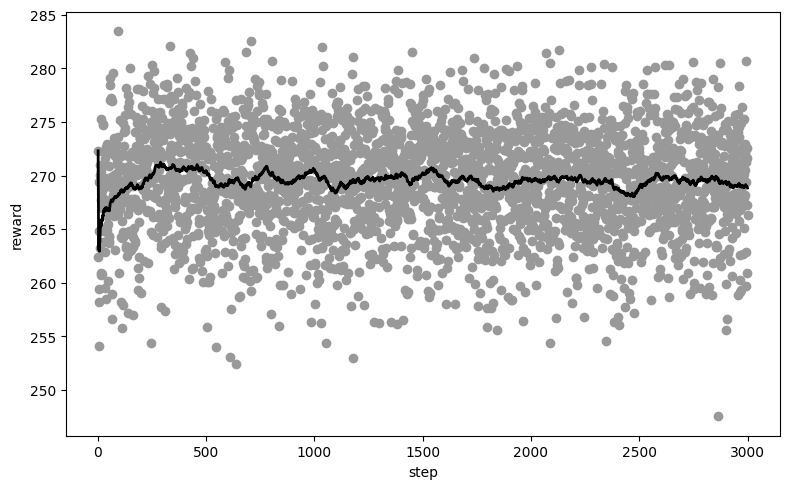

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt


def plot_reward(
    df,
    x_col="iteration",
    y_col="avg_reward",
    save_path=None,
    scatter=False,
    color=None,
    add_smooth_line=False,
    smooth_window=100,
    smooth_color="black",
    smooth_linewidth=2,
    figsize=(8, 5),
    dpi=160,
    show=True,
):
    plot_df = df[[x_col, y_col]].sort_values(by=x_col)

    fig, ax = plt.subplots(figsize=figsize)

    if scatter:
        ax.scatter(plot_df[x_col], plot_df[y_col], color=color)
    else:
        ax.plot(plot_df[x_col], plot_df[y_col], color=color)

    if add_smooth_line:
        y_smooth = plot_df[y_col].rolling(window=smooth_window, min_periods=1).mean()
        ax.plot(
            plot_df[x_col],
            y_smooth,
            color=smooth_color,
            linewidth=smooth_linewidth,
        )

    ax.set_xlabel("step")
    ax.set_ylabel("reward")

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    if show:
        plt.show()

    plt.close(fig)
    
plot_reward(df, scatter=True, save_path="outputs/figures/aaaaa.png", color="0.6",              # gray points
    add_smooth_line=True,
    smooth_window=100,)

In [ ]:
import numpy as np
import pandas as pd

from src.otc_mm.constants import (
    ARRIVAL_RATES,
    AVG_SIZES,
    RF,
    subset_array,
    subset_cov,
    subset_f_parameters,
)
from src.otc_mm.market import Market
from src.otc_mm.utils import load_single_bond_targets


def make_selected_market(selected_bonds, seed=42):
    selected_bonds = list(map(int, selected_bonds))
    return Market(
        lambdas_RFQ=subset_array(ARRIVAL_RATES, selected_bonds),
        Sigma=subset_cov(selected_bonds),
        rf=RF,
        sizes=subset_array(AVG_SIZES, selected_bonds),
        f_parameters=subset_f_parameters(selected_bonds),
        seed=seed,
    )


def ensure_prob_quote_columns(
    df: pd.DataFrame,
    market: Market,
    bond_idx_col: str | None = None,
    default_local_bond_idx: int | None = None,
    bid_quote_col: str = "optimal_delta_bid",
    ask_quote_col: str = "optimal_delta_ask",
    bid_prob_col: str = "optimal_prob_bid",
    ask_prob_col: str = "optimal_prob_ask",
) -> pd.DataFrame:
    """
    Add whichever columns are missing among:
      - optimal_delta_bid / optimal_prob_bid
      - optimal_delta_ask / optimal_prob_ask

    You must provide either:
      - bond_idx_col: a column containing the LOCAL bond index in the selected basket
        (for a 2-bond run, typically 0 or 1)
      - or default_local_bond_idx for a single-bond dataframe or a per-bond slice.
    """
    out = df.copy()

    if bond_idx_col is None and default_local_bond_idx is None:
        raise ValueError("Provide either bond_idx_col or default_l ocal_bond_idx")

    if bond_idx_col is None:
        bond_ids = np.full(len(out), int(default_local_bond_idx), dtype=int)
    else:
        bond_ids = out[bond_idx_col].astype(int).to_numpy()

    def _compute_prob_from_delta(delta_values, local_bond_ids):
        p = np.empty(len(delta_values), dtype=np.float32)
        for j in np.unique(local_bond_ids):
            mask = (local_bond_ids == j)
            p[mask] = np.asarray(
                market.f(int(j), delta_values[mask]),
                dtype=np.float32,
            )
        return p

    def _compute_delta_from_prob(prob_values, local_bond_ids):
        delta = np.empty(len(prob_values), dtype=np.float32)
        for j in np.unique(local_bond_ids):
            mask = (local_bond_ids == j)
            delta[mask] = np.asarray(
                market.inv_f(int(j), prob_values[mask]),
                dtype=np.float32,
            )
        return delta

    # Bid side
    if bid_quote_col in out.columns and bid_prob_col not in out.columns:
        out[bid_prob_col] = _compute_prob_from_delta(
            out[bid_quote_col].to_numpy(dtype=np.float32),
            bond_ids,
        )

    if bid_prob_col in out.columns and bid_quote_col not in out.columns:
        out[bid_quote_col] = _compute_delta_from_prob(
            out[bid_prob_col].to_numpy(dtype=np.float32),
            bond_ids,
        )

    # Ask side
    if ask_quote_col in out.columns and ask_prob_col not in out.columns:
        out[ask_prob_col] = _compute_prob_from_delta(
            out[ask_quote_col].to_numpy(dtype=np.float32),
            bond_ids,
        )

    if ask_prob_col in out.columns and ask_quote_col not in out.columns:
        out[ask_quote_col] = _compute_delta_from_prob(
            out[ask_prob_col].to_numpy(dtype=np.float32),
            bond_ids,
        )

    return out

In [65]:
import pandas as pd
from pathlib import Path

# Single-bond saved dataset
tgt = load_single_bond_targets(0)

df_single = pd.DataFrame({
    "inventory": tgt["inventories"],
    "value": tgt["values"],
    "optimal_delta_bid": tgt["deltas_bid"],
    "optimal_delta_ask": tgt["deltas_ask"],
})

# IMPORTANT:
# for a single-bond selected market, the local bond index is always 0
market_single = make_selected_market([0])

df_single = ensure_prob_quote_columns(
    df_single,
    market=market_single,
    default_local_bond_idx=0,
)

df_single.to_csv("single_bond_00_optimal_quotes_probs.csv", index=False)
print(df_single.head())

   inventory        value  optimal_delta_bid  optimal_delta_ask  \
0   -35000.0 -2446.882812           0.059856           0.340312   
1   -28000.0 -1728.728760           0.061756           0.312180   
2   -21000.0 -1018.130005           0.070411           0.286401   
3   -14000.0  -488.675385           0.084576           0.241096   
4    -7000.0  -143.781174           0.103717           0.190509   

   optimal_prob_bid  optimal_prob_ask  
0          0.438521          0.072128  
1          0.433690          0.082054  
2          0.411376          0.093208  
3          0.374284          0.119682  
4          0.324999          0.166077  


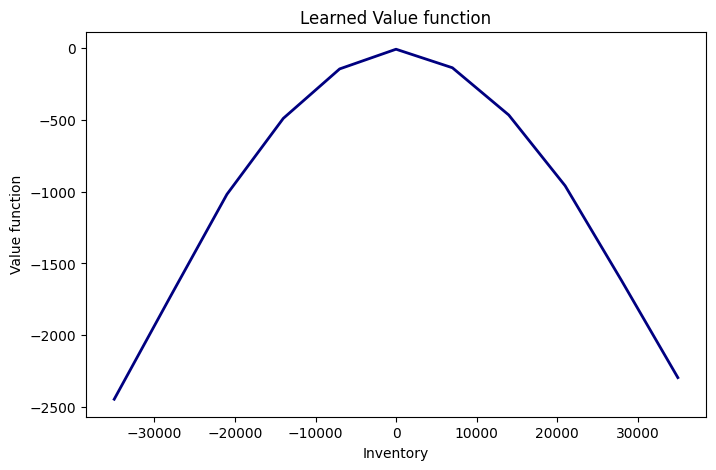

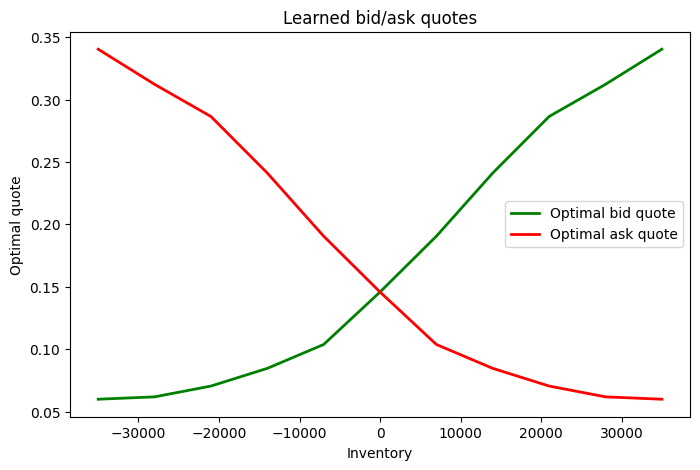

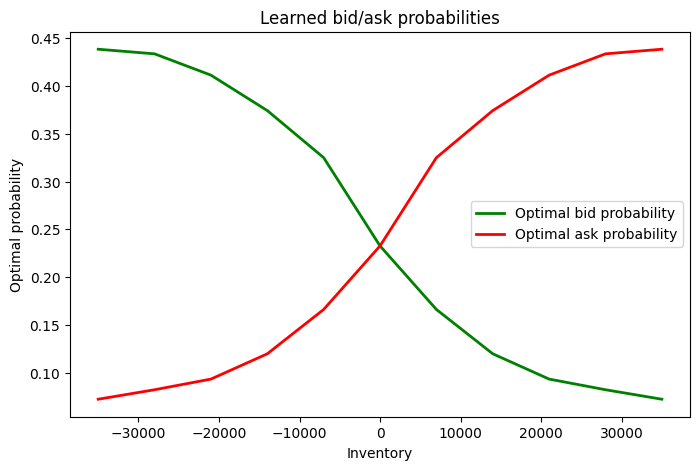

In [67]:
import matplotlib.pyplot as plt

x = df_single["inventory"]

plt.figure(figsize=(8, 5))
plt.plot(x, df_single["value"], color="navy", linewidth=2)
plt.xlabel("Inventory")
plt.ylabel("Value function")
plt.title("Learned Value function")
plt.grid(False)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(x, df_single["optimal_delta_bid"], color="green", linewidth=2, label="Optimal bid quote")
plt.plot(x, df_single["optimal_delta_ask"], color="red", linewidth=2, label="Optimal ask quote")
plt.xlabel("Inventory")
plt.ylabel("Optimal quote")
plt.title("Learned bid/ask quotes")
plt.legend()
plt.grid(False)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(x, df_single["optimal_prob_bid"], color="green", linewidth=2, label="Optimal bid probability")
plt.plot(x, df_single["optimal_prob_ask"], color="red", linewidth=2, label="Optimal ask probability")
plt.xlabel("Inventory")
plt.ylabel("Optimal probability")
plt.title("Learned bid/ask probabilities")
plt.legend()
plt.grid(False)
plt.show()

In [ ]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from mpl_toolkits.mplot3d import Axes3D

from src.otc_mm.experiments import run_multi_bond_experiment


# ============================================================
# SETTINGS
# ============================================================
SELECTED_BONDS = [0, 5]   # global bond ids
HIDDEN_DIM = 12
NB_STEPS = 300

LONG_HORIZON = 10_000
NB_SHORT_ROLLOUTS = 100
SHORT_HORIZON = 100

SEED = 42
DEVICE = "cpu"

# Plot grid
GRID_WIDTH_IN_SIZES = 5   # plot q_j in {-5s, ..., +5s}
OUT_DIR = Path(
    f"outputs/plots_2bond/bonds_{SELECTED_BONDS[0]:02d}_{SELECTED_BONDS[1]:02d}"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# HELPERS
# ============================================================
def build_inventory_grid(sizes: np.ndarray, width: int = 5):
    axes = [
        np.arange(-width * sizes[j], (width + 1) * sizes[j], sizes[j], dtype=np.float32)
        for j in range(len(sizes))
    ]
    mesh = np.meshgrid(*axes, indexing="ij")
    q = np.stack([m.ravel() for m in mesh], axis=1).astype(np.float32)
    return axes, q


def actor_probs_and_quotes(actor, market, local_bond_idx: int, x_norm: np.ndarray):
    """
    Symmetric actor convention:
    - bid  -> actor( q / sizes )
    - ask  -> actor(-q / sizes )
    """
    with torch.inference_mode():
        x_bid_t = torch.as_tensor(x_norm, dtype=torch.float32)
        x_ask_t = torch.as_tensor(-x_norm, dtype=torch.float32)

        p_bid = actor(x_bid_t)
        p_ask = actor(x_ask_t)

        if p_bid.dim() == 2:
            p_bid = p_bid[:, 0]
        if p_ask.dim() == 2:
            p_ask = p_ask[:, 0]

        p_bid = p_bid.detach().cpu().numpy().astype(np.float32)
        p_ask = p_ask.detach().cpu().numpy().astype(np.float32)

    p_bid = np.clip(p_bid, 1e-6, 1.0 - 1e-6)
    p_ask = np.clip(p_ask, 1e-6, 1.0 - 1e-6)

    delta_bid = np.asarray(market.inv_f(local_bond_idx, p_bid), dtype=np.float32)
    delta_ask = np.asarray(market.inv_f(local_bond_idx, p_ask), dtype=np.float32)

    return p_bid, p_ask, delta_bid, delta_ask


def critic_values(critic, x_norm: np.ndarray):
    with torch.inference_mode():
        x_t = torch.as_tensor(x_norm, dtype=torch.float32)
        v = critic(x_t)
        if v.dim() == 2:
            v = v[:, 0]
        return v.detach().cpu().numpy().astype(np.float32)



# ============================================================
# 1) RETRAIN THE 2-BOND MODEL
# ============================================================
result = run_multi_bond_experiment(
    selected_bonds=SELECTED_BONDS,
    hidden_dim=HIDDEN_DIM,
    nb_steps=NB_STEPS,
    long_horizon=LONG_HORIZON,
    nb_short_rollouts=NB_SHORT_ROLLOUTS,
    short_horizon=SHORT_HORIZON,
    seed=SEED,
    device=DEVICE,
)

actors = result["actors"]
critic = result["critic"]
market = result["market"]
sizes = np.asarray(result["sizes"], dtype=np.float32)


In [45]:
def save_surface(df, x_col, y_col, value_col, title, out_file, cmap= "viridis"):
    pivot = df.pivot(index=y_col, columns=x_col, values=value_col).sort_index().sort_index(axis=1)

    x_vals = pivot.columns.to_numpy(dtype=float)
    y_vals = pivot.index.to_numpy(dtype=float)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = pivot.to_numpy(dtype=float)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(X, Y, Z, cmap= cmap)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_zlabel(value_col)
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(out_file, dpi=160)
    plt.close()

In [52]:

# ============================================================
# 2) BUILD A 2D INVENTORY GRID
# ============================================================
axes, q_grid = build_inventory_grid(sizes=sizes, width=GRID_WIDTH_IN_SIZES)
x_norm = q_grid / sizes.reshape(1, -1)

q_col_0 = f"Inventory bond {SELECTED_BONDS[0]+1}"
q_col_1 = f"Inventory bond {SELECTED_BONDS[1]+1}"

# ============================================================
# 3) CRITIC SURFACE
# ============================================================
v = critic_values(critic, x_norm)

critic_df = pd.DataFrame({
    q_col_0: q_grid[:, 0],
    q_col_1: q_grid[:, 1],
    "Value": v,
})

critic_df.to_csv(OUT_DIR / "critic_surface.csv", index=False)

save_surface(
    critic_df,
    x_col=q_col_1,
    y_col=q_col_0,
    value_col="Value",
    title=f"Learned value surface for bonds 1 and 6",
    out_file=OUT_DIR / "critic_value_surface.png",
)

# ============================================================
# 4) ACTOR SURFACES: probs and quotes
# ============================================================
all_actor_rows = []

for local_j, global_bond in enumerate(SELECTED_BONDS):
    p_bid, p_ask, delta_bid, delta_ask = actor_probs_and_quotes(
        actor=actors[local_j],
        market=market,
        local_bond_idx=local_j,
        x_norm=x_norm,
    )

    df_j = pd.DataFrame({
        q_col_0: q_grid[:, 0],
        q_col_1: q_grid[:, 1],
        "bond_local_idx": local_j,
        "bond_global_idx": global_bond,
        "Bid probability": p_bid,
        "Ask probability": p_ask,
        "Bid quote": delta_bid,
        "Ask quote": delta_ask,
    })

    df_j.to_csv(OUT_DIR / f"actor_surface_bond_{global_bond:02d}.csv", index=False)
    all_actor_rows.append(df_j)

    save_surface(
    df_j,
    x_col=q_col_1,
    y_col=q_col_0,
    value_col="Bid probability",
    title=f"Bond {global_bond+1} - optimal bid probability",
    out_file=OUT_DIR / f"bond_{global_bond:02d}_prob_bid_surface.png",cmap="magma"
    
    )

    save_surface(
        df_j,
        x_col=q_col_1,
        y_col=q_col_0,
        value_col="Ask probability",
        title=f"Bond {global_bond+1} - optimal ask probability",
        out_file=OUT_DIR / f"bond_{global_bond:02d}_prob_ask_surface.png",cmap="magma"
    )

    save_surface(
        df_j,
        x_col=q_col_1,
        y_col=q_col_0,
        value_col="Bid quote",
        title=f"Bond {global_bond+1} - optimal bid quote",
        out_file=OUT_DIR / f"bond_{global_bond:02d}_quote_bid_surface.png",cmap="magma"
    )

    save_surface( 
        df_j,
        x_col=q_col_1,
        y_col=q_col_0,
        value_col="Ask quote",
        title=f"Bond {global_bond+1} - optimal ask quote",
        out_file=OUT_DIR / f"bond_{global_bond:02d}_quote_ask_surface.png",cmap="magma"
    )

actor_df = pd.concat(all_actor_rows, axis=0, ignore_index=True)
# actor_df.to_csv(OUT_DIR / "all_actor_surfaces.csv", index=False)
